<a href="https://colab.research.google.com/github/xKABIRAJ/gz/blob/main/GD_reg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [59]:
X, y = make_regression(n_samples = 100 , n_features = 1, n_informative =1 , n_targets = 1 , noise = 20, random_state = 13)

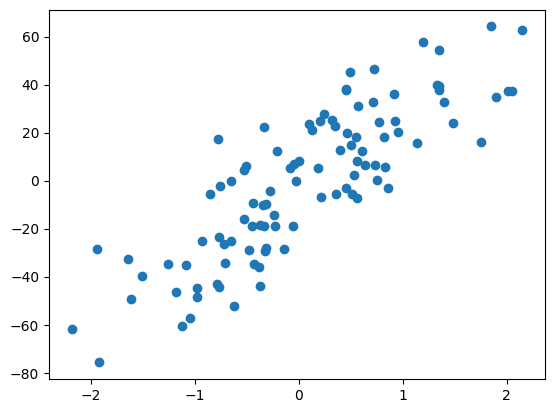

In [60]:
plt.scatter(X,y)

In [71]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2 , random_state = 2)

In [61]:
from sklearn.linear_model import LinearRegression

In [62]:
lr = LinearRegression()

In [72]:
lr.fit(X_train,y_train)
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [73]:
y_pred = lr.predict(X_test)

from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.6357827506345679

In [64]:
np.mean(cross_val_score(lr,X,y,scoring = 'r2',cv = 10))

np.float64(0.6375011587464419)

In [65]:
class GDRegressor:
  def __init__( self,learning_rate,epochs):
    self.m = 100
    self.b = -120
    self.lr = learning_rate
    self.epochs = epochs

  def fit(self, X,y):
    #Calculating the b using GD
    for i in range(self.epochs):
      loss_slope_b = -2 * np.sum(y - self.m * X.ravel() - self.b)

      loss_slope_m = -2 * np.sum((y - self.m* X.ravel() - self.b) * X.ravel())
      self.b = self.b - (self.lr * loss_slope_b)
      self.m = self.m - (self.lr * loss_slope_m)
      print(self.m,self.b)

  def predict(self,X):
    return self.m * X + self.b


    print(self.b)

In [66]:
gd = GDRegressor (0.001, 50)

In [67]:
gd.fit(X,y)

88.7901778060777 -97.30202349511147
79.26989400677363 -79.01269499728718
71.19603915550572 -64.2700212110887
64.357826042914 -52.381567622457695
58.573134285938856 -42.79092431395032
53.685100591058074 -35.05083591632167
49.55898969983806 -28.80166573902754
46.07935938462746 -23.754130522644466
43.14751810732243 -19.6754551237646
40.679264258689464 -16.378266564607884
38.602889878179504 -13.711682863685132
36.85742837440565 -11.55416078082497
35.391124246007365 -9.807753543980294
34.160102562818395 -8.393499154751025
33.12721658147269 -7.2477154903755485
32.2610530264308 -6.3190229237706514
31.53507604240516 -5.5659507997754325
30.926892458014258 -4.955012616245335
30.417622682493505 -4.459157586120731
29.991363212652477 -4.056524538225423
29.63472830753753 -3.7294387591921634
29.33645986404345 -3.4636041130856206
29.087095882238803 -3.2474521798712006
28.87868913818444 -3.071617693375023
28.70456878480573 -2.928515605334555
28.559138582490913 -2.811999951784896
28.437706327772243 -2.7

In [68]:
gd.predict(X)

array([[-22.13004587],
       [-14.46803398],
       [-14.93031641],
       [ 24.22481941],
       [  4.3220791 ],
       [ 21.67440917],
       [ -9.07267152],
       [  2.84916767],
       [-22.36969544],
       [-14.266255  ],
       [ 53.79864004],
       [  8.75884689],
       [  3.48535872],
       [ -8.76923699],
       [-23.69550079],
       [ 10.31541979],
       [ 15.51330493],
       [  7.70913832],
       [-47.25904197],
       [ 46.39456556],
       [-24.26231913],
       [-16.55078722],
       [-28.14130775],
       [ 57.56115677],
       [ -8.07119002],
       [-47.92672634],
       [-11.72532075],
       [-11.26615965],
       [-15.69914914],
       [-16.86253782],
       [ 17.79820103],
       [ 19.02152826],
       [ 10.32439521],
       [-37.41858492],
       [-63.18204405],
       [-35.29775901],
       [  3.75403106],
       [ 34.73292872],
       [-32.56312362],
       [ 13.35252918],
       [-44.41234489],
       [ -2.36568738],
       [-10.04163129],
       [ 10

In [74]:
y_pred = gd.predict(X_test)

from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.6357499569549734